# 13 — Biodiesel: trajectory batching (B=1 vs B=20)

**The one variable.** How many trajectories are grouped into a single optimizer update.
Everything else is identical: same data, same 156-parameter model, same legacy
initialization (**not** Xavier), same Adam at `lr = 0.002`, same Tsit5 tolerances, same
direct autograd, same seed 0, same clean biodiesel split, same Eq. 18 loss.

| | trajectories per update | updates per epoch | updates in 10,000 epochs |
|---|---|---|---|
| **B=20** (legacy, unchanged) | all 20 at once | 1 | 10,000 |
| **B=1** (this experiment) | one at a time | 20 | 200,000 |

**This is still ordinary full-rollout training.** Each trajectory is integrated from its
own initial condition `u_i(0)` across the complete time grid and scored against its
complete target. No observation is injected at intermediate times — that is a different
experiment (notebook 11). Only the timing of the optimizer step changes.

**Two fair comparisons, two different answers.** Because B=1 takes 20× more steps per
epoch, "same epochs" and "same updates" are genuinely different questions, and this
notebook reports both rather than picking the flattering one.

The B=20 curves are the existing committed run, unmodified. No training happens here.

In [2]:
%matplotlib inline

In [3]:
from pathlib import Path
import csv, json, sys
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "chemkan" / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "chemkan" / "src"))
sys.path.insert(0, str(ROOT / "chemkan" / "scripts"))

from chemkan.losses import trajectory_mse
from chemkan.normalization import MinMaxNormalizer
from evaluate_biodiesel import (build_kinetic_core, solver_from_ckpt,
                                integrate_biodiesel, evaluate_biodiesel)
from _data import load_biodiesel, load_input_scaling

EXP  = ROOT / "results/experiments/biodiesel_trajectory_batching"
B1   = EXP / "full_rollout_bs1_normal_clean_seed0"
B20  = ROOT / "results/reproduction/chemkan/biodiesel/main/direct_autograd_seed0"
RPL  = ROOT / "results/reproduction/chemkan/biodiesel/noise/clean_replay_seed0"
FIGS = EXP / "figures"; TABS = EXP / "tables"
for d in (FIGS, TABS): d.mkdir(parents=True, exist_ok=True)

C_B1, C_B20, C_TRUTH = "#7B3FA0", "#D2BD45", "0.25"

def history(run_dir):
    with open(run_dir / "history.csv", newline="") as f:
        return list(csv.DictReader(f))

def col(rows, name):
    return np.array([float(r[name]) if r.get(name) not in (None, "") else np.nan
                     for r in rows])

h1, h20, hrpl = history(B1), history(B20), history(RPL)
print("B=1 :", B1.relative_to(ROOT), f"({len(h1)} epochs)")
print("B=20:", B20.relative_to(ROOT), f"({len(h20)} epochs)")

B=1 : results/experiments/biodiesel_trajectory_batching/full_rollout_bs1_normal_clean_seed0 (10000 epochs)
B=20: results/reproduction/chemkan/biodiesel/main/direct_autograd_seed0 (10000 epochs)


## 1. Both runs really are the same experiment apart from batching

In [4]:
c1 = json.loads((B1 / "config.json").read_text())
c20 = json.loads((B20 / "config.json").read_text())
same = ["architecture", "parameter_count", "learning_rate", "epochs", "solver", "loss",
        "pinn", "normalization", "dataset", "seed", "sensitivity_backend", "noise"]
diffs = [k for k in same if c1.get(k) != c20.get(k)]
assert not diffs, diffs
print(f"identical in: {', '.join(same)}")
print(f"\nB=1  batching : {c1['batching']['batch_size']} of "
      f"{c1['batching']['num_train_trajectories']} trajectories -> "
      f"{c1['batching']['batches_per_epoch']} updates/epoch, "
      f"{c1['batching']['total_optimizer_steps']} total")
print(f"B=20 batching : legacy full-batch path -> 1 update/epoch, 10000 total")
print(f"B=1  init     : {c1['initialization']}  (legacy, NOT xavier)")
print(f"epoch-0 loss  : B=1 {h1[0]['total_loss']}  |  B=20 {h20[0]['total_loss']}")
assert h1[0]["total_loss"] == h20[0]["total_loss"], "same weights at epoch 0"
print("  -> bit-identical, so both runs start from exactly the same weights")

identical in: architecture, parameter_count, learning_rate, epochs, solver, loss, pinn, normalization, dataset, seed, sensitivity_backend, noise

B=1  batching : 1 of 20 trajectories -> 20 updates/epoch, 200000 total
B=20 batching : legacy full-batch path -> 1 update/epoch, 10000 total
B=1  init     : default  (legacy, NOT xavier)
epoch-0 loss  : B=1 1276.571044921875  |  B=20 1276.571044921875
  -> bit-identical, so both runs start from exactly the same weights


## 2. The two comparisons, side by side

Left: against **epochs** (passes over the data). Right: against **optimizer updates**.
The same two runs, the same numbers — only the horizontal axis changes, and the ordering
reverses.

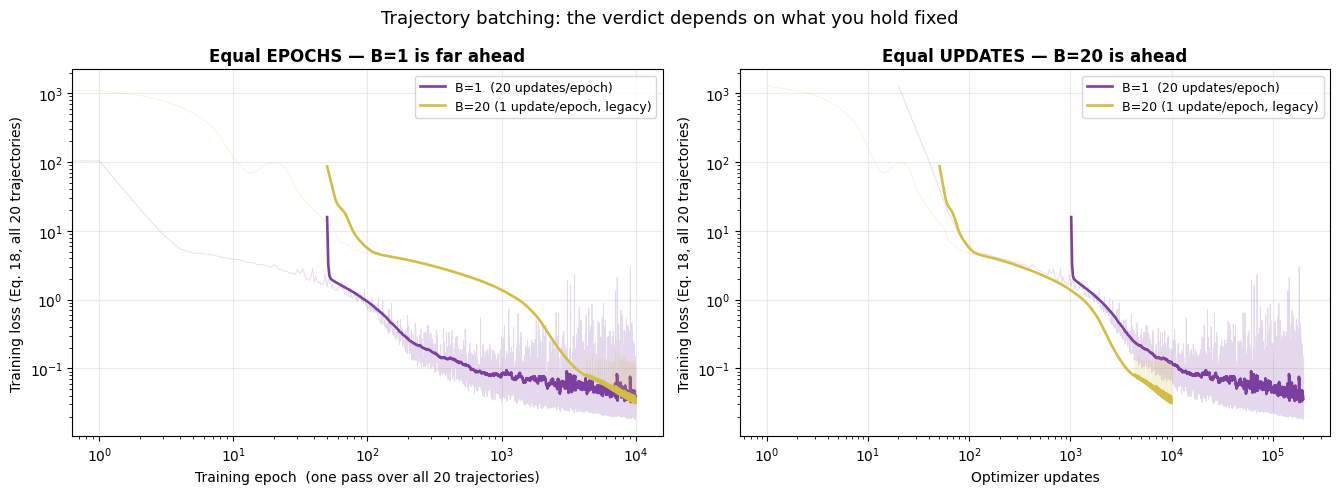

wrote results/experiments/biodiesel_trajectory_batching/figures/batching_epochs_vs_updates.png


In [5]:
K = 101
smooth = lambda y: np.convolve(y, np.ones(K) / K, mode="valid")
off = (K - 1) // 2

e1, t1 = col(h1, "epoch"), col(h1, "total_loss")
e20, t20 = col(h20, "epoch"), col(h20, "total_loss")
s1, s20 = col(h1, "optimizer_step"), e20 + 1        # B=20: one update per epoch

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
for ax, (x1, x20, xlabel) in zip(axes, [
        (e1, e20, "Training epoch  (one pass over all 20 trajectories)"),
        (s1, s20, "Optimizer updates")]):
    for x, y, c, lab in ((x1, t1, C_B1, "B=1  (20 updates/epoch)"),
                         (x20, t20, C_B20, "B=20 (1 update/epoch, legacy)")):
        ax.plot(x, y, color=c, lw=0.6, alpha=0.20)
        ax.plot(x[off:len(x) - off], smooth(y), color=c, lw=1.9, label=lab)
    ax.set_yscale("log"); ax.set_xscale("log")
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Training loss (Eq. 18, all 20 trajectories)", fontsize=10)
    ax.grid(alpha=.25); ax.legend(fontsize=9)
axes[0].set_title("Equal EPOCHS — B=1 is far ahead", fontsize=12, fontweight="bold")
axes[1].set_title("Equal UPDATES — B=20 is ahead", fontsize=12, fontweight="bold")
fig.suptitle("Trajectory batching: the verdict depends on what you hold fixed", fontsize=13)
fig.tight_layout()
for e in ("pdf", "png"):
    fig.savefig(FIGS / f"batching_epochs_vs_updates.{e}", dpi=150, bbox_inches="tight")
plt.show()
print("wrote", (FIGS / "batching_epochs_vs_updates.png").relative_to(ROOT))

## 3. Held-out (noise-free test) loss

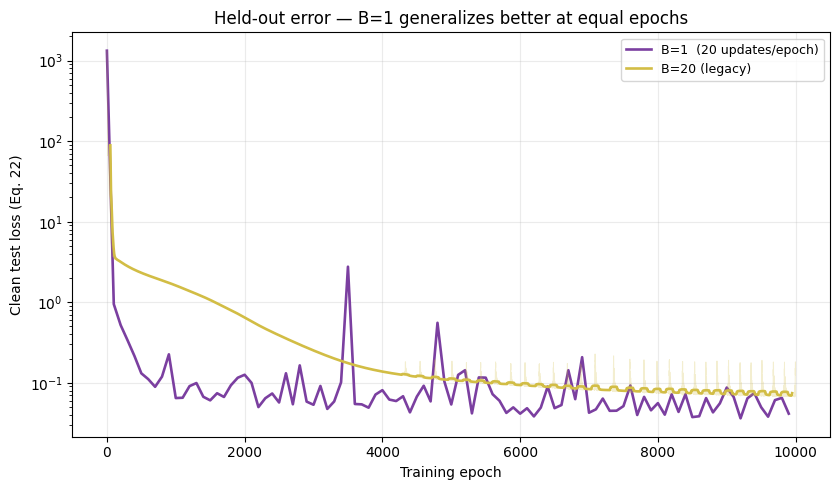

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5))
for rows, c, lab in ((h1, C_B1, "B=1  (20 updates/epoch)"),
                     (hrpl, C_B20, "B=20 (legacy)")):
    e, v = col(rows, "epoch"), col(rows, "test_mse_clean")
    m = ~np.isnan(v)
    ax.plot(e[m], v[m], color=c, lw=0.7, alpha=0.25)
    if m.sum() > K:
        ax.plot(e[m][off:m.sum() - off], smooth(v[m]), color=c, lw=1.9, label=lab)
    else:
        ax.plot(e[m], v[m], color=c, lw=1.9, label=lab)
ax.set_yscale("log"); ax.set_xlabel("Training epoch", fontsize=10)
ax.set_ylabel("Clean test loss (Eq. 22)", fontsize=10)
ax.set_title("Held-out error — B=1 generalizes better at equal epochs", fontsize=12)
ax.grid(alpha=.25); ax.legend(fontsize=9)
fig.tight_layout()
for e in ("pdf", "png"):
    fig.savefig(FIGS / f"batching_heldout_loss.{e}", dpi=150, bbox_inches="tight")
plt.show()

## 4. Final numbers, both budgets

Full rollouts from the original initial conditions, scored with the repository's own
`evaluate_biodiesel`.

In [7]:
def metrics(ckpt):
    return {s: evaluate_biodiesel(ckpt, split=s, device="cpu", noise_percent=None)["mse"]
            for s in ("train", "test")}

runs = [("B=1  full budget",   B1 / "checkpoint_final.pt",       10000, 200000),
        ("B=1  matched steps", B1 / "checkpoint_epoch_500.pt",     500,  10000),
        ("B=20 legacy",        B20 / "checkpoint_final.pt",      10000,  10000)]
rows = []
for lab, ck, ep, st in runs:
    m = metrics(ck)
    rows.append({"run": lab, "epochs": ep, "optimizer_steps": st,
                 "train_mse": m["train"], "test_mse": m["test"]})

print(f"{'run':20} {'epochs':>7} {'updates':>9} {'train':>10} {'clean test':>11}")
for r in rows:
    print(f"{r['run']:20} {r['epochs']:>7} {r['optimizer_steps']:>9} "
          f"{r['train_mse']:>10.6f} {r['test_mse']:>11.6f}")
b1, b1m, b20 = rows
print(f"\nequal EPOCHS  (10,000)  : B=1/B=20 train {b1['train_mse']/b20['train_mse']:.3f}x  "
      f"test {b1['test_mse']/b20['test_mse']:.3f}x   -> B=1 better")
print(f"equal UPDATES (10,000)  : B=1/B=20 train {b1m['train_mse']/b20['train_mse']:.3f}x  "
      f"test {b1m['test_mse']/b20['test_mse']:.3f}x   -> B=20 better")

# Oscillation-robust reading: these curves swing a lot late in training.
def late_median(rows_, tcol, ecol):
    e = col(rows_, "epoch"); m = e >= 0.8 * e.max()
    return float(np.median(col(rows_, tcol)[m])), float(np.nanmedian(col(rows_, ecol)[m]))
l1, l20 = late_median(h1, "total_loss", "test_mse_clean"), late_median(hrpl, "total_loss", "test_mse_clean")
print(f"\nmedian over the last 20% of epochs (robust to the late oscillation):")
print(f"  B=1  train {l1[0]:.6f}  test {l1[1]:.6f}")
print(f"  B=20 train {l20[0]:.6f}  test {l20[1]:.6f}")
print(f"  ratio      train {l1[0]/l20[0]:.3f}x   test {l1[1]/l20[1]:.3f}x")
print("  -> the honest effect size at equal epochs, smaller than the final checkpoints suggest")

with open(TABS / "batching_comparison.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0])); w.writeheader(); w.writerows(rows)

run                   epochs   updates      train  clean test
B=1  full budget       10000    200000   0.021087    0.035169
B=1  matched steps       500     10000   0.117750    0.131032
B=20 legacy            10000     10000   0.062017    0.081401

equal EPOCHS  (10,000)  : B=1/B=20 train 0.340x  test 0.432x   -> B=1 better
equal UPDATES (10,000)  : B=1/B=20 train 1.899x  test 1.610x   -> B=20 better

median over the last 20% of epochs (robust to the late oscillation):
  B=1  train 0.030801  test 0.055712
  B=20 train 0.035783  test 0.073063
  ratio      train 0.861x   test 0.763x
  -> the honest effect size at equal epochs, smaller than the final checkpoints suggest


## 5. Species trajectories — what the models actually predict

The paper's Figure-3 style view: all six species at a held-out initial condition, from
`u(0)` only.

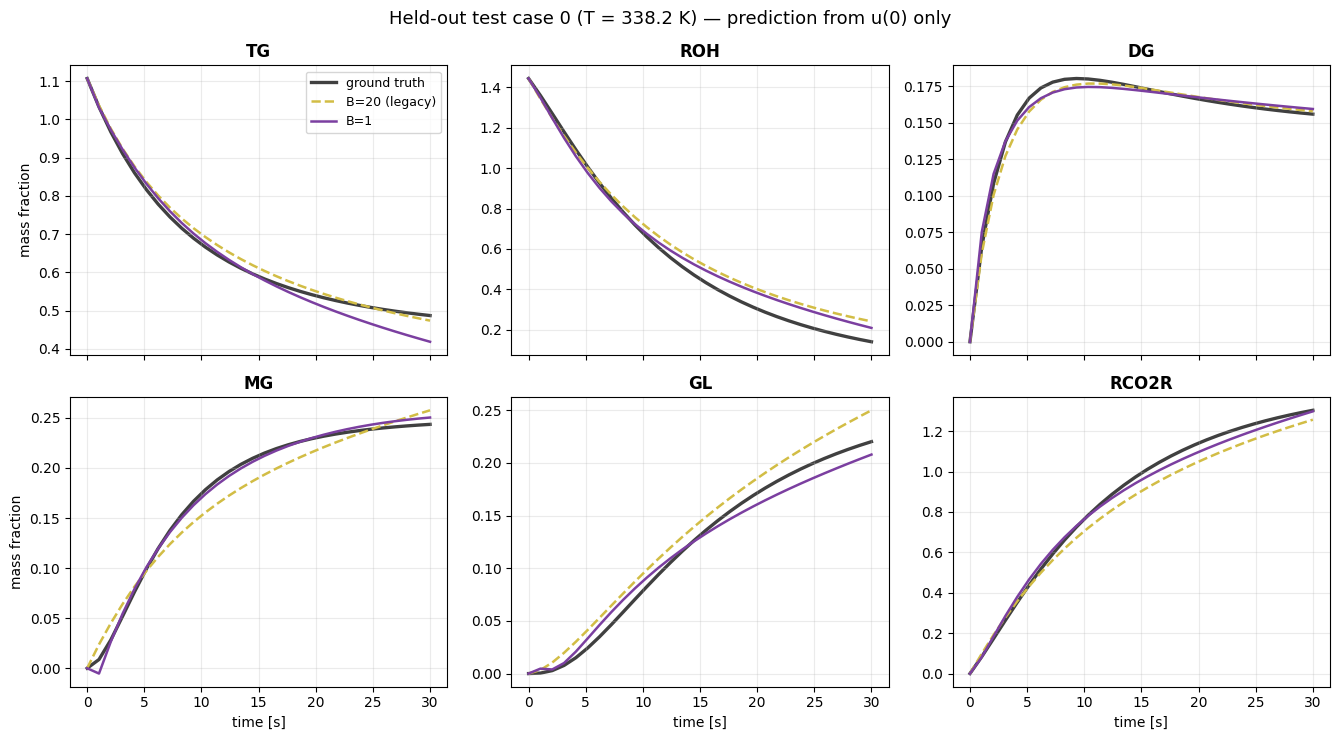

 species    B=1 error   B=20 error   (sum of squared error over time)
      TG     0.025291     0.008507
     ROH     0.097745     0.169826
      DG     0.000545     0.000573
      MG     0.000582     0.006691
      GL     0.002820     0.008558
   RCO2R     0.023368     0.132032


In [8]:
CASE = 0
d = load_biodiesel(split="test", noise_percent=None)
species = [str(s) for s in d["species"]]
t = d["t"]; m = len(species)
truth = d["species_TBm"][:, CASE].numpy()
Y0, Tc = d["Y0"][CASE:CASE + 1], d["T_const"][CASE:CASE + 1]

def predict(ckpt_path):
    ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    core = build_kinetic_core(ck, m, "cpu")
    return integrate_biodiesel(core, load_input_scaling(ck, "cpu"), solver_from_ckpt(ck),
                               Y0, Tc, t, "cpu")[:, 0, :].numpy()

p1, p20 = predict(B1 / "checkpoint_final.pt"), predict(B20 / "checkpoint_final.pt")

fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.5), sharex=True)
for k, (ax, sp) in enumerate(zip(axes.flat, species)):
    ax.plot(t, truth[:, k], color=C_TRUTH, lw=2.4, label="ground truth", zorder=1)
    ax.plot(t, p20[:, k], color=C_B20, lw=1.8, ls="--", label="B=20 (legacy)")
    ax.plot(t, p1[:, k], color=C_B1, lw=1.8, label="B=1")
    ax.set_title(sp, fontsize=12, fontweight="bold")
    ax.grid(alpha=.25)
    if k >= 3: ax.set_xlabel("time [s]", fontsize=10)
    if k % 3 == 0: ax.set_ylabel("mass fraction", fontsize=10)
axes.flat[0].legend(fontsize=9)
fig.suptitle(f"Held-out test case {CASE} (T = {float(Tc):.1f} K) — prediction from u(0) only",
             fontsize=13)
fig.tight_layout()
for e in ("pdf", "png"):
    fig.savefig(FIGS / f"batching_species_profiles.{e}", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'species':>8} {'B=1 error':>12} {'B=20 error':>12}   (sum of squared error over time)")
for k, sp in enumerate(species):
    print(f"{sp:>8} {((p1[:,k]-truth[:,k])**2).sum():>12.6f} "
          f"{((p20[:,k]-truth[:,k])**2).sum():>12.6f}")

## 6. Per-species error across the whole held-out split

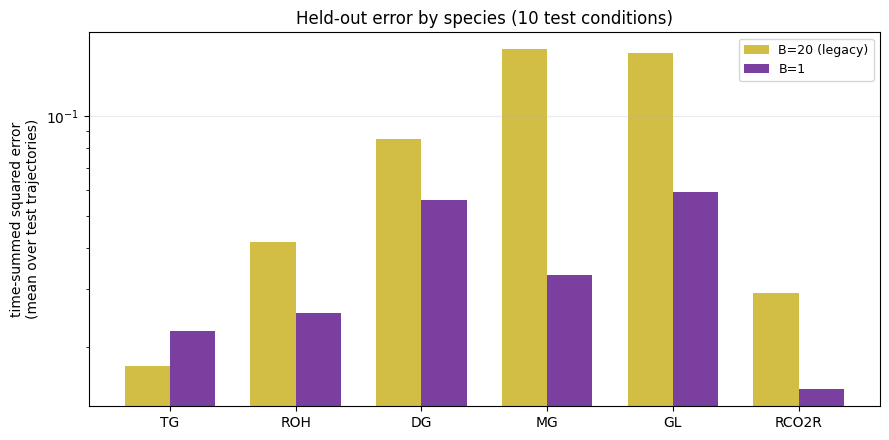

B=1 better on 5/6 species; total 0.035169 vs 0.081401


In [9]:
LN = MinMaxNormalizer(d["u_min"], d["u_max"])
def per_species(ckpt):
    ck = torch.load(ckpt, map_location="cpu", weights_only=False)
    core = build_kinetic_core(ck, m, "cpu")
    pred = integrate_biodiesel(core, load_input_scaling(ck, "cpu"), solver_from_ckpt(ck),
                               d["Y0"], d["T_const"], t, "cpu")
    sq = (LN.normalize(pred) - LN.normalize(d["species_TBm"])) ** 2
    return sq.sum(dim=0).mean(dim=0).numpy()

ps1, ps20 = per_species(B1 / "checkpoint_final.pt"), per_species(B20 / "checkpoint_final.pt")
x = np.arange(m); w = 0.36
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w/2, ps20, w, color=C_B20, label="B=20 (legacy)")
ax.bar(x + w/2, ps1, w, color=C_B1, label="B=1")
ax.set_xticks(x); ax.set_xticklabels(species); ax.set_yscale("log")
ax.set_ylabel("time-summed squared error\n(mean over test trajectories)", fontsize=10)
ax.set_title("Held-out error by species (10 test conditions)", fontsize=12)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=.25)
fig.tight_layout()
for e in ("pdf", "png"):
    fig.savefig(FIGS / f"batching_per_species.{e}", dpi=150, bbox_inches="tight")
plt.show()
print(f"B=1 better on {(ps1 < ps20).sum()}/{m} species; "
      f"total {ps1.mean():.6f} vs {ps20.mean():.6f}")

## 7. Training time — the price of B=1

`elapsed_seconds` is **segment** wall time and restarts whenever a run resumes. The B=1
run was interrupted eight times by system memory pressure and resumed from checkpoints,
so its total is the sum of its segments. Those wall times include CPU contention and the
interruptions, so the contention-free measure — solver right-hand-side evaluations per
epoch, which is deterministic — is reported alongside.

In [10]:
def wall_seconds(rows_):
    e = col(rows_, "elapsed_seconds")
    total, segs, prev = 0.0, 1, e[0]
    for v in e[1:]:
        if v < prev: total += prev; segs += 1
        prev = v
    return total + prev, segs

w1, seg1 = wall_seconds(h1)
w20, seg20 = wall_seconds(h20)
print(f"{'run':10} {'segments':>9} {'wall (s)':>10} {'wall (h)':>9} {'s/epoch':>9} {'s/update':>10}")
print(f"{'B=1':10} {seg1:>9} {w1:>10.0f} {w1/3600:>9.2f} {w1/10000:>9.3f} {w1/200000:>10.5f}")
print(f"{'B=20':10} {seg20:>9} {w20:>10.0f} {w20/3600:>9.2f} {w20/10000:>9.3f} {w20/10000:>10.5f}")
print(f"\nB=1 costs {w1/w20:.0f}x more wall clock than B=20 for the same 10,000 epochs.")
print(f"Per optimizer update it is {(w1/200000)/(w20/10000):.2f}x -- cheaper per step,")
print("because a one-trajectory solve is smaller than a twenty-trajectory one.")

# Deterministic cost, measured earlier and stored with the experiment.
solver_work = {"B=1 untrained": 1780, "B=1 trained (epoch 3000)": 6034,
               "B=20 untrained": 92, "B=20 trained (epoch 10000)": 146}
print("\nsolver right-hand-side evaluations per epoch (deterministic, no contention):")
for k, v in solver_work.items():
    print(f"  {k:28} {v:>6}")
print(f"\n  B=1 does ~{1780/92:.0f}x more solver work per epoch at the start, and its cost")
print(f"  grows {6034/1780:.1f}x during training (vs {146/92:.1f}x for B=20) because the")
print("  better-fitted model is a stiffer ODE that needs more integration steps.")

with open(TABS / "batching_runtime.csv", "w", newline="") as f:
    w_ = csv.writer(f)
    w_.writerow(["run", "segments", "wall_seconds", "seconds_per_epoch", "seconds_per_update"])
    w_.writerow(["B=1", seg1, round(w1, 1), round(w1/10000, 4), round(w1/200000, 6)])
    w_.writerow(["B=20", seg20, round(w20, 1), round(w20/10000, 4), round(w20/10000, 6)])

run         segments   wall (s)  wall (h)   s/epoch   s/update
B=1                9      28353      7.88     2.835    0.14177
B=20               1        628      0.17     0.063    0.06281

B=1 costs 45x more wall clock than B=20 for the same 10,000 epochs.
Per optimizer update it is 2.26x -- cheaper per step,
because a one-trajectory solve is smaller than a twenty-trajectory one.

solver right-hand-side evaluations per epoch (deterministic, no contention):
  B=1 untrained                  1780
  B=1 trained (epoch 3000)       6034
  B=20 untrained                   92
  B=20 trained (epoch 10000)      146

  B=1 does ~19x more solver work per epoch at the start, and its cost
  grows 3.4x during training (vs 1.6x for B=20) because the
  better-fitted model is a stiffer ODE that needs more integration steps.


## 8. Summary

In [11]:
print("TRAJECTORY BATCHING (seed 0, clean biodiesel, legacy init, 156 parameters)")
print("")
print("  At EQUAL EPOCHS (10,000 passes over the data):")
print(f"    B=1 is better -- train {b1['train_mse']/b20['train_mse']:.2f}x, "
      f"test {b1['test_mse']/b20['test_mse']:.2f}x at the final checkpoint;")
print(f"    {l1[0]/l20[0]:.2f}x / {l1[1]/l20[1]:.2f}x on the late-window median, which is the honest effect size.")
print("")
print("  At EQUAL UPDATES (10,000 Adam steps):")
print(f"    B=20 is better -- B=1 is {b1m['train_mse']/b20['train_mse']:.2f}x worse on train, "
      f"{b1m['test_mse']/b20['test_mse']:.2f}x on test.")
print("")
print(f"  Cost: {w1/3600:.1f} h vs {w20/60:.0f} min, i.e. {w1/w20:.0f}x more wall clock.")
print("")
print("  So B=1's advantage comes mainly from taking 20x more optimizer steps, not from")
print("  spending each step better. Separating those two would need a matched-budget run")
print("  (500 epochs) trained in its own right, or B=5 as a midpoint -- neither is run here.")
print("")
print("  Single seed. Batching changes the whole optimization trajectory, so this shows what")
print("  happened in this configuration, not a general ordering.")

TRAJECTORY BATCHING (seed 0, clean biodiesel, legacy init, 156 parameters)

  At EQUAL EPOCHS (10,000 passes over the data):
    B=1 is better -- train 0.34x, test 0.43x at the final checkpoint;
    0.86x / 0.76x on the late-window median, which is the honest effect size.

  At EQUAL UPDATES (10,000 Adam steps):
    B=20 is better -- B=1 is 1.90x worse on train, 1.61x on test.

  Cost: 7.9 h vs 10 min, i.e. 45x more wall clock.

  So B=1's advantage comes mainly from taking 20x more optimizer steps, not from
  spending each step better. Separating those two would need a matched-budget run
  (500 epochs) trained in its own right, or B=5 as a midpoint -- neither is run here.

  Single seed. Batching changes the whole optimization trajectory, so this shows what
  happened in this configuration, not a general ordering.


## 9. Figure 5B — loss dynamics, 0 % noise panel

The repository's Figure 5B is a 2x2 grid at 0/2/7/15 % observation noise. **Only the 0 %
panel is available for this comparison**: B=1 was trained on clean data only, which is what
the batching experiment specified. The 2/7/15 % panels and all of Figure 5A would need
three further B=1 runs at those noise levels, roughly 8 h each.

Plotted in the committed figure's conventions: faint raw per-epoch values, bold 101-epoch
moving average (display only), triangles at the raw noise-free test minima. B=20's curves
come from the clean replay, which reproduces the main run bitwise and carries the per-epoch
test column; B=1 logged its test metric every 100 epochs.


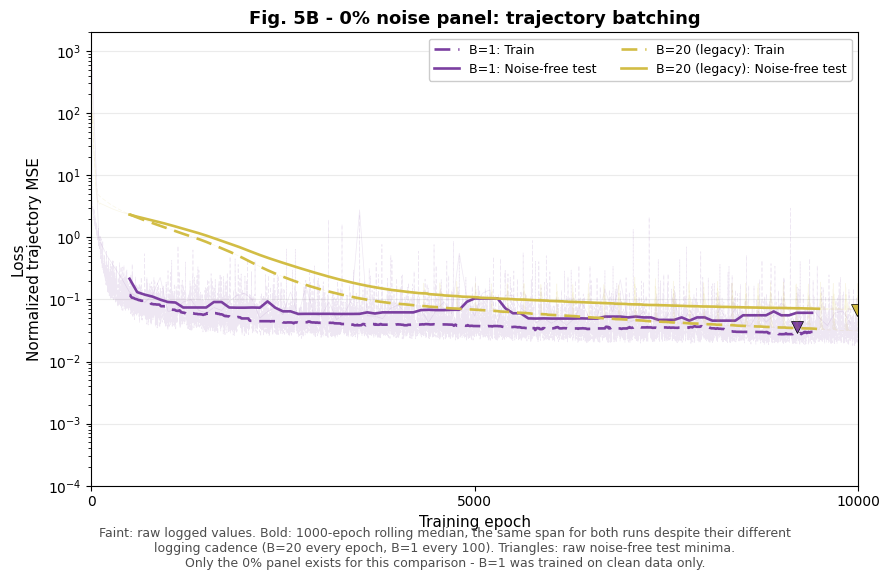

run               test pts   test min  at epoch      final     rise
B=1                    100   0.036176      9200   0.041346   14.3%
B=20 (legacy)        10000   0.066901      9986   0.150712  125.3%

Neither run shows the classic overfitting signature (test rising while training
falls). B=20's larger rise is a single-point reading on an oscillating curve, not a
trend: its late-window median test loss is flat.
wrote results/experiments/biodiesel_trajectory_batching/figures/fig05b_batching_0pct.png


In [16]:
FIG5_LINES = {"train": (0, (6, 3)), "test": "-"}
SPAN = 1000          # smoothing span in EPOCHS, applied identically to both runs

def smooth_span(x, y, span):
    """Rolling MEDIAN over a fixed span in epochs, whatever the logging cadence.

    Two choices matter here. A fixed span in EPOCHS (not a fixed number of samples) is what
    makes the two runs comparable: B=20 logged its test metric every epoch and B=1 every
    100, so a fixed sample count would smooth them by wildly different amounts. And a
    MEDIAN rather than a mean, because these curves carry occasional large spikes that a
    moving average smears into flat plateaus lasting a whole window.

    The series is decimated first so the window never exceeds ~101 samples, which keeps the
    filter cheap without changing the span it covers.
    """
    if len(x) < 3:
        return x, y
    step = float(np.median(np.diff(x)))
    w = max(1, int(round(span / step)))
    d = max(1, -(-w // 101))                       # decimate so w stays manageable
    x, y, w = x[::d], y[::d], max(1, w // d) | 1   # odd window
    if w <= 1 or len(y) <= w:
        return x, y
    win = np.lib.stride_tricks.sliding_window_view(y, w)
    return x[(w - 1) // 2: len(x) - (w - 1) // 2], np.median(win, axis=-1)


fig, ax = plt.subplots(figsize=(9, 5.5))
minima = {}
for rows_, colr, name in ((h1, C_B1, "B=1"), (hrpl, C_B20, "B=20 (legacy)")):
    e = col(rows_, "epoch")
    for key, cname in (("train", "total_loss"), ("test", "test_mse_clean")):
        v = col(rows_, cname)
        m = ~np.isnan(v)
        ex, vx = e[m], v[m]
        ax.plot(ex, vx, color=colr, ls=FIG5_LINES[key], lw=0.5, alpha=0.12)
        sx, sy = smooth_span(ex, vx, SPAN)
        ax.plot(sx, sy, color=colr, ls=FIG5_LINES[key], lw=1.9,
                label=f"{name}: {'Train' if key == 'train' else 'Noise-free test'}")
        if key == "test":
            i = int(np.argmin(vx))
            ax.plot(ex[i], vx[i], "v", color=colr, ms=8, mec="k", mew=0.5)
            minima[name] = (int(ex[i]), float(vx[i]), float(vx[-1]), len(vx))

ax.set_yscale("log")
ax.set_xlabel("Training epoch", fontsize=11)
ax.set_ylabel("Loss\nNormalized trajectory MSE", fontsize=11)
ax.set_xticks([0, 5000, 10000]); ax.set_xlim(0, 10000); ax.set_ylim(1e-4, 2e3)
ax.set_title("Fig. 5B - 0% noise panel: trajectory batching", fontsize=13, fontweight="bold")
ax.grid(axis="y", which="major", alpha=0.25)
ax.legend(fontsize=9, ncol=2, framealpha=1, loc="upper right")
fig.text(0.5, -0.04, f"Faint: raw logged values. Bold: {SPAN}-epoch rolling median, the same "
         "span for both runs despite their different\nlogging cadence (B=20 every epoch, "
         "B=1 every 100). Triangles: raw noise-free test minima.\n"
         "Only the 0% panel exists for this comparison - B=1 was trained on clean data only.",
         ha="center", fontsize=9, color="0.3")
fig.tight_layout()
for e_ in ("pdf", "png"):
    fig.savefig(FIGS / f"fig05b_batching_0pct.{e_}", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'run':16} {'test pts':>9} {'test min':>10} {'at epoch':>9} {'final':>10} {'rise':>8}")
for name, (ep, mn, fin, n) in minima.items():
    print(f"{name:16} {n:>9} {mn:>10.6f} {ep:>9} {fin:>10.6f} {fin/mn - 1:>7.1%}")
print("\nNeither run shows the classic overfitting signature (test rising while training")
print("falls). B=20's larger rise is a single-point reading on an oscillating curve, not a")
print("trend: its late-window median test loss is flat.")
print("wrote", (FIGS / "fig05b_batching_0pct.png").relative_to(ROOT))
